In [27]:
import pandas as pd


In [ ]:
import os
os.getcwd()

'/Users/theodore/Desktop/aiml1-sheffield-collisions/notebooks'

In [ ]:
df = pd.read_csv("data/raw/dft-road-casualty-statistics-collision-1979-latest-published-year.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/dft-road-casualty-statistics-collision-1979-latest-published-year.csv'

In [ ]:
import os
os.getcwd()

'/Users/theodore/Desktop/aiml1-sheffield-collisions/notebooks'

In [ ]:
df = pd.read_csv("../data/raw/dft-road-casualty-statistics-collision-1979-latest-published-year.csv")

In [ ]:
df.head()


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2018450290294,2018,450290294,487906.0,132932.0,-0.746206,51.088970,45,3,2,...,0,0,1,2,2,E01030927,3,1,0.000000,1.000000
1,2020230984311,2020,230984311,433493.0,258232.0,-1.511123,52.221299,23,2,5,...,0,13,2,1,1,E01031199,6,1,1.000000,0.000000
2,1998929800391,1998,929800391,391100.0,803100.0,NaN,NaN,92,3,1,...,0,0,2,-1,-1,-1,-1,-1,NaN,NaN
3,1996950661096,1996,950661096,331410.0,673460.0,NaN,NaN,95,3,2,...,0,0,1,-1,-1,-1,-1,-1,NaN,NaN
4,2006620156303,2006,620156303,300660.0,202130.0,-3.439174,51.709037,62,3,2,...,0,0,1,1,-1,W01001150,-1,0,0.021371,0.978629


## Data Loading and File Handling

The dataset was loaded using the pandas library. Initially, an error occurred due to an incorrect file path when attempting to read the CSV file.

The error (`FileNotFoundError`) indicated that the specified path did not match the actual file location. This was resolved by adjusting the file path to correctly reference the dataset directory.

Specifically, the working directory was identified using `os.getcwd()`, which showed that the notebook was located in the `notebooks` folder. Therefore, the file path was updated to move one level up using `../` to access the `data/raw` directory.

After correcting the path, the dataset was successfully loaded and verified using `df.head()`.

In [ ]:
df.shape

(9015100, 44)

In [ ]:
df.columns

Index(['collision_index', 'collision_year', 'collision_ref_no',
       'location_easting_osgr', 'location_northing_osgr', 'longitude',
       'latitude', 'police_force', 'collision_severity', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'local_authority_district', 'local_authority_ons_district',
       'local_authority_highway', 'local_authority_highway_current',
       'first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail_historic', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control_historic',
       'pedestrian_crossing_physical_facilities_historic',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards_historic', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
 

In [ ]:
df["local_authority_district"].unique()[:20]


array([517, 293, 910, 923, 744,   7, 924, 938, 751, 741, 416, 564, 560,
       911, 935,  -1, 126, 325, 555, 437])

In [ ]:
df["local_authority_ons_district"].unique()[:20]

<StringArray>
['E07000216', 'E07000221', 'S12000033', 'S12000036', 'W06000016', 'E09000023',
 'S12000014', 'S12000029', 'W06000010', 'W06000015', 'E07000206', 'E07000229',
 'E07000226', 'S12000034', 'S12000038', 'S12000049', 'E10000004', 'E07000037',
 'E07000064', 'E07000103']
Length: 20, dtype: str

In [ ]:
df["local_authority_highway_current"].unique()[:20]


<StringArray>
['E10000030', 'E10000031',         nan, 'W06000016', 'E09000023', 'S12000014',
 'W06000015', 'E10000029', 'E10000032', 'S12000034', 'S12000038', 'S12000049',
 'E06000049', 'E10000011', 'E10000015', 'E10000020', 'E10000034', 'W06000020',
 'E08000035', 'E09000003']
Length: 20, dtype: str

In [ ]:
sheffield_df = df[df["local_authority_ons_district"] == "E08000019"]

## Data Understanding and Filtering

The dataset contains over 9 million records and 44 variables, providing detailed information about road collisions across the UK. These variables include geographic data, environmental conditions, and collision characteristics such as severity, number of vehicles, and number of casualties.

To understand the structure of the dataset, the column names were inspected, revealing a wide range of features related to road conditions, location, and accident details.

Several location-based variables were explored, including `local_authority_district`, `local_authority_ons_district`, and `local_authority_highway_current`. These columns contain coded values representing different regions.

The `local_authority_ons_district` column was identified as the most suitable for filtering, as it uses standardised geographic codes. The code **E08000019** corresponds to Sheffield.

The dataset was therefore filtered to include only collisions occurring in Sheffield:


In [ ]:
sheffield_df.shape

(43412, 44)

In [ ]:
sheffield_df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
628,200514D151505,2005,14D151505,435910.0,389680.0,-1.461345,53.402715,14,2,1,...,0,0,1,1,2,E01007869,-1,0,1.000000,0.000000
1514,199914HH00487,1999,14HH00487,443640.0,381260.0,-1.346245,53.326453,14,3,3,...,0,0,1,-1,2,E01008023,-1,-1,NaN,NaN
1880,200714G118607,2007,14G118607,435830.0,387460.0,-1.462800,53.382766,14,3,1,...,2,17,1,1,2,E01007884,-1,0,0.248913,0.751087
2039,200214KK01181,2002,14KK01181,439370.0,387820.0,-1.409537,53.385751,14,3,1,...,0,0,1,-1,2,E01007907,-1,-1,NaN,NaN
2316,200414EE00565,2004,14EE00565,444030.0,381380.0,-1.340373,53.327500,14,2,2,...,0,0,1,-1,2,E01008019,-1,0,1.000000,0.000000


In [ ]:
df.shape

(9015100, 44)

In [ ]:
df = pd.read_csv("../data/raw/dft-road-casualty-statistics-collision-1979-latest-published-year.csv")
df.shape

(9015100, 44)

In [ ]:
sheffield_df.shape

(43412, 44)

In [ ]:
sheffield_df.to_csv("../data/processed/sheffield_collisions.csv", index=False)

In [ ]:
sheffield_df.info()

<class 'pandas.DataFrame'>
Index: 43412 entries, 628 to 9011488
Data columns (total 44 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   collision_index                                   43412 non-null  str    
 1   collision_year                                    43412 non-null  int64  
 2   collision_ref_no                                  43412 non-null  str    
 3   location_easting_osgr                             42816 non-null  float64
 4   location_northing_osgr                            42816 non-null  float64
 5   longitude                                         34105 non-null  float64
 6   latitude                                          34105 non-null  float64
 7   police_force                                      43412 non-null  int64  
 8   collision_severity                                43412 non-null  int64  
 9   number_of_vehicles           

## Dataset Reduction and Verification

After filtering the dataset to include only Sheffield collisions, the size of the dataset was significantly reduced.

The original dataset contained over 9 million records and 44 variables:

- Original dataset shape: (9,015,100, 44)

After filtering using the Sheffield local authority code (E08000019), the dataset was reduced to:

- Filtered dataset shape: (43,412, 44)

This reduction allows for a more focused analysis while still maintaining a sufficiently large dataset for machine learning tasks.

A preview of the dataset (`head()`) confirms that the data contains relevant variables such as collision severity, number of vehicles, and number of casualties.

Additionally, the dataset was saved to a new file (`sheffield_collisions.csv`) for easier reuse and to separate raw and processed data.

Finally, the structure of the dataset was examined using `info()`, which provided details about data types and missing values across the columns.

In [ ]:
sheffield_df["accident_severity"].value_counts()

KeyError: 'accident_severity'

In [ ]:
sheffield_df.columns

Index(['collision_index', 'collision_year', 'collision_ref_no',
       'location_easting_osgr', 'location_northing_osgr', 'longitude',
       'latitude', 'police_force', 'collision_severity', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'local_authority_district', 'local_authority_ons_district',
       'local_authority_highway', 'local_authority_highway_current',
       'first_road_class', 'first_road_number', 'road_type', 'speed_limit',
       'junction_detail_historic', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control_historic',
       'pedestrian_crossing_physical_facilities_historic',
       'pedestrian_crossing', 'light_conditions', 'weather_conditions',
       'road_surface_conditions', 'special_conditions_at_site',
       'carriageway_hazards_historic', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
 

In [ ]:
sheffield_df["collision_severity"].value_counts()

collision_severity
3    36056
2     6943
1      413
Name: count, dtype: int64

## Collision Severity Distribution

Initially, an error occurred when attempting to access the `accident_severity` column. This resulted in a `KeyError`, indicating that the column name did not exist in the dataset.

To resolve this, the column names were inspected using `sheffield_df.columns`, which revealed that the correct column name is `collision_severity`.

After correcting the column name, the distribution of collision severity was analysed using `value_counts()`.

The results show that:

- Slight collisions (3) are the most common: 36,056 cases  
- Serious collisions (2): 6,943 cases  
- Fatal collisions (1): 413 cases  

This demonstrates a significant class imbalance in the dataset, with the majority of collisions being classified as slight.

This imbalance is an important factor that affects machine learning models, particularly classification, as models may become biased towards predicting the majority class.

Matplotlib is building the font cache; this may take a moment.


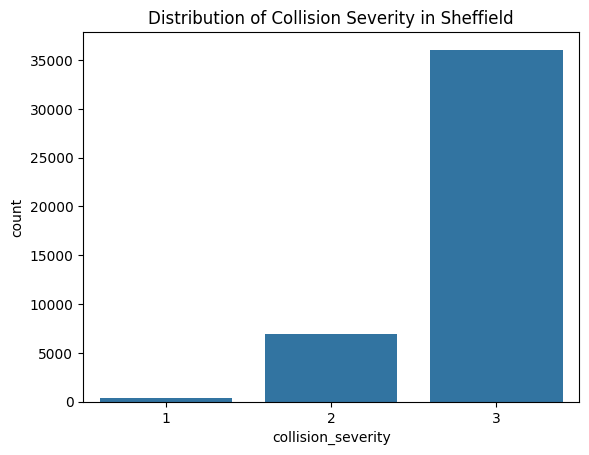

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="collision_severity", data=sheffield_df)

plt.title("Distribution of Collision Severity in Sheffield")
plt.show()

In [ ]:
sheffield_df["speed_limit"].value_counts()

speed_limit
30.0    35211
40.0     4506
60.0     1267
20.0      877
70.0      846
50.0      704
5.0         1
Name: count, dtype: int64

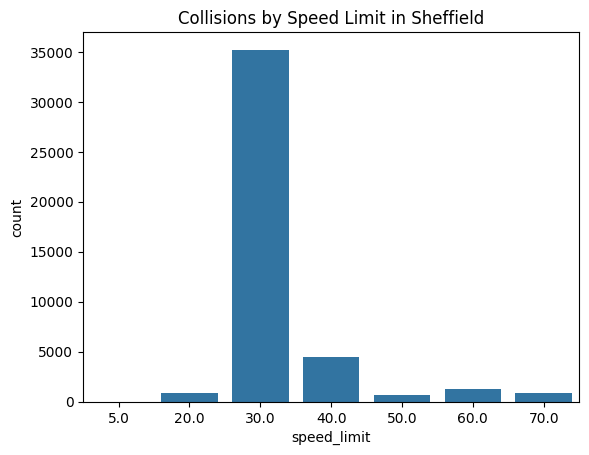

In [ ]:
sns.countplot(x="speed_limit", data=sheffield_df)

plt.title("Collisions by Speed Limit in Sheffield")
plt.show()

In [ ]:
pd.crosstab(sheffield_df["speed_limit"], sheffield_df["collision_severity"])

collision_severity,1,2,3
speed_limit,,,
5.0,0,0,1
20.0,5,186,686
30.0,254,5464,29493
40.0,69,778,3659
50.0,18,137,549
60.0,50,300,917
70.0,17,78,751


In [ ]:
pd.crosstab(
    sheffield_df["speed_limit"],
    sheffield_df["collision_severity"],
    normalize="index"
) * 100

collision_severity,1,2,3
speed_limit,,,
5.0,0.000000,0.000000,100.000000
20.0,0.570125,21.208666,78.221209
30.0,0.721365,15.517878,83.760757
40.0,1.531292,17.265868,81.202841
50.0,2.556818,19.460227,77.982955
60.0,3.946330,23.677979,72.375691
70.0,2.009456,9.219858,88.770686


In [ ]:
sheffield_df.isnull().sum()

collision_index                                         0
collision_year                                          0
collision_ref_no                                        0
location_easting_osgr                                 596
location_northing_osgr                                596
longitude                                            9307
latitude                                             9307
police_force                                            0
collision_severity                                      0
number_of_vehicles                                      0
number_of_casualties                                    0
date                                                    0
day_of_week                                             0
time                                                    0
local_authority_district                                0
local_authority_ons_district                            0
local_authority_highway                                 0
local_authorit

In [ ]:
sheffield_df["number_of_casualties"].value_counts()

number_of_casualties
1     33801
2      6488
3      1971
4       759
5       227
6        91
7        42
8        15
9         6
10        3
14        3
20        1
13        1
16        1
17        1
22        1
11        1
Name: count, dtype: int64

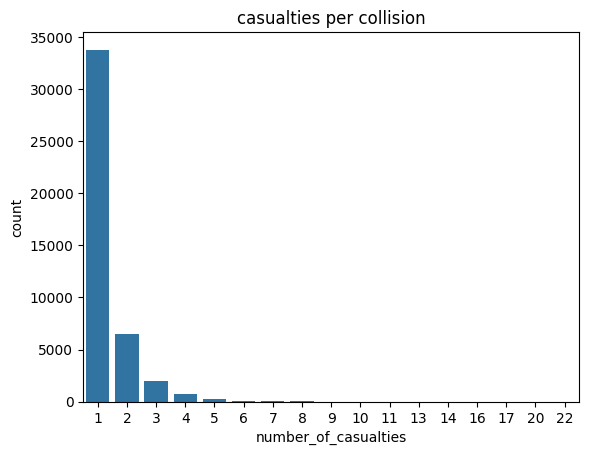

In [ ]:
sns.countplot(x="number_of_casualties", data=sheffield_df)

plt.title("casualties per collision")
plt.show()

In [ ]:
sheffield_df["number_of_casualties"].value_counts()

number_of_casualties
1     33801
2      6488
3      1971
4       759
5       227
6        91
7        42
8        15
9         6
10        3
14        3
20        1
13        1
16        1
17        1
22        1
11        1
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    sheffield_df["number_of_vehicles"],
    sheffield_df["number_of_casualties"]
)


number_of_casualties,1,2,3,4,5,6,7,8,9,10,11,13,14,16,17,20,22
number_of_vehicles,,,,,,,,,,,,,,,,,
1,13370,1016,236,92,19,9,1,4,1,0,1,0,1,0,1,0,0
2,18296,4573,1296,516,156,53,28,5,3,3,0,1,1,1,0,0,1
3,1805,721,344,101,30,14,7,3,0,0,0,0,1,0,0,1,0
4,252,133,70,34,11,8,3,2,1,0,0,0,0,0,0,0,0
5,58,29,15,13,9,3,0,1,1,0,0,0,0,0,0,0,0
6,11,9,8,1,1,3,1,0,0,0,0,0,0,0,0,0,0
7,5,5,2,0,1,0,2,0,0,0,0,0,0,0,0,0,0
8,2,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
9,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
sheffield_df[[
    "speed_limit",
    "number_of_vehicles",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
]].head()

,speed_limit,number_of_vehicles,weather_conditions,light_conditions,road_surface_conditions
628,30.0,1,1,4,2
1514,40.0,3,1,1,1
1880,30.0,1,1,4,1
2039,30.0,1,1,1,1
2316,30.0,2,1,1,1


In [ ]:
features = [
    "speed_limit",
    "number_of_vehicles",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
]

X = sheffield_df[features]
y = sheffield_df["number_of_casualties"]

In [ ]:
X_encoded = pd.get_dummies(X, columns=[
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
])

In [ ]:
X_encoded.head()

,speed_limit,number_of_vehicles,weather_conditions_1,weather_conditions_2,weather_conditions_3,weather_conditions_4,weather_conditions_5,weather_conditions_6,weather_conditions_7,weather_conditions_8,...,light_conditions_4,light_conditions_5,light_conditions_6,light_conditions_7,road_surface_conditions_-1,road_surface_conditions_1,road_surface_conditions_2,road_surface_conditions_3,road_surface_conditions_4,road_surface_conditions_5
628,30.0,1,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1514,40.0,3,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1880,30.0,1,True,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
2039,30.0,1,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2316,30.0,2,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape

((34729, 22), (8683, 22))

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/dft-road-casualty-statistics-collision-1979-latest-published-year.csv")

sheffield_df = df[df["local_authority_ons_district"] == "E08000019"]


In [ ]:
features = [
    "speed_limit",
    "number_of_vehicles",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
]

X = sheffield_df[features]
y = sheffield_df["number_of_casualties"]


In [ ]:
X_encoded = pd.get_dummies(X, columns=[
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.477846710799201


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
3758404,1,1.336341
955398,1,1.336234
4314602,1,1.336234
2949520,1,1.344811
285341,1,1.336234
7359412,1,1.372026
4460029,1,1.336234
4516580,2,1.743903
773200,1,1.085279
2240747,1,1.085279


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import mean_absolute_error
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)

Random Forest MAE: 0.48079227326939095


In [ ]:
features = [
    "speed_limit",
    "number_of_vehicles",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions",
    "collision_severity"   
]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.477846710799201


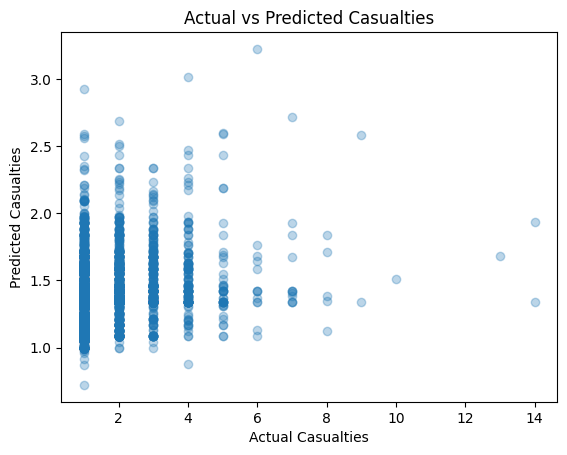

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Casualties")
plt.ylabel("Predicted Casualties")
plt.title("Actual vs Predicted Casualties")
plt.show()

In [ ]:
features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties", 
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
]

X = sheffield_df[features]
y = sheffield_df["collision_severity"]

In [ ]:
X_encoded = pd.get_dummies(X, columns=[
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8335828630657607


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[   0    2   72]
 [   3   16 1298]
 [   3   67 7222]]


In [ ]:
clf = RandomForestClassifier(class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5673154439709778
[[  15   32   27]
 [ 250  450  617]
 [ 850 1981 4461]]


In [ ]:
features = [
    "number_of_vehicles",
    "number_of_casualties",
    "speed_limit"
]

X_cluster = sheffield_df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
sheffield_df["cluster"] = clusters

In [ ]:
sheffield_df.groupby("cluster")[features].mean()

,number_of_vehicles,number_of_casualties,speed_limit
cluster,,,
0,1.558378,1.027780,30.757283
1,1.967105,1.597588,60.789474
2,2.392259,2.262720,31.501405


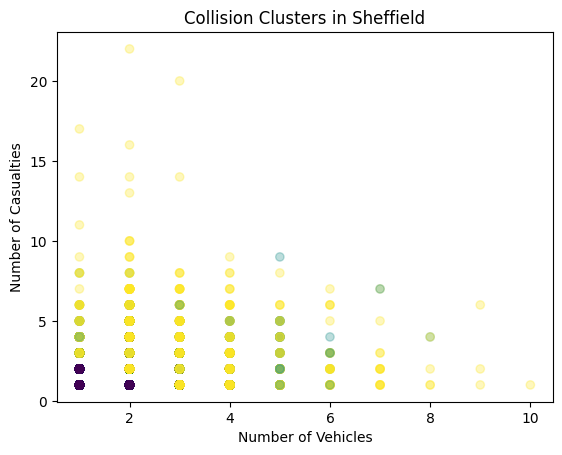

In [26]:
import matplotlib.pyplot as plt

plt.scatter(
    sheffield_df["number_of_vehicles"],
    sheffield_df["number_of_casualties"],
    c=sheffield_df["cluster"],
    alpha=0.3
)

plt.xlabel("Number of Vehicles")
plt.ylabel("Number of Casualties")
plt.title("Collision Clusters in Sheffield")
plt.show()